
# Traffic Sign Recognition with 4GB dataset

This is ready to use preprocessed data for Traffic Signs saved into the nine pickle files.

**Original Datasets**

* train.pickle

* valid.pickle

* test.pickle

Code with detailed description on how datasets were preprocessed is in `datasets_preparing.py`

Before preprocessing training dataset was equalized making examples in the classes equal as it is shown on the figure below. Histogram of 43 classes for training dataset with their number of examples for Traffic Signs Classification before and after equalization by adding transformed images (brightness and rotation) from original dataset. After equalization, training dataset has increased up to 86989 examples.




**Preprocessed Datasets**

* data0.pickle - Shuffling

* data1.pickle - Shuffling, /255.0 Normalization

* data2.pickle - Shuffling, /255.0 + Mean Normalization

* data3.pickle - Shuffling, /255.0 + Mean + STD Normalization

* data4.pickle - Grayscale, Shuffling

* data5.pickle - Grayscale, Shuffling, Local Histogram Equalization

* data6.pickle - Grayscale, Shuffling, Local Histogram Equalization, /255.0 Normalization

* data7.pickle - Grayscale, Shuffling, Local Histogram Equalization, /255.0 + Mean Normalization

* data8.pickle - Grayscale, Shuffling, Local Histogram Equalization, /255.0 + Mean + STD Normalization


**Shapes of data0 - data3 are as following (RGB):**

- x_train: (86989, 3, 32, 32)
- y_train: (86989,)
- x_validation: (4410, 3, 32, 32)
- y_validation: (4410,)
- x_test: (12630, 3, 32, 32)
- y_test: (12630,)

**Shapes of data4 - data8 are as following (Gray):**
- x_train: (86989, 1, 32, 32)
- y_train: (86989,)
- x_validation: (4410, 1, 32, 32)
- y_validation: (4410,)
- x_test: (12630, 1, 32, 32)
- y_test: (12630,)


`mean_image` and `standard_deviation` were calculated from `train` dataset and applied to `validation` and `testing` datasets for appropriate datasets. When using user's image for classification, it has to be preprocessed firstly in the same way and in the same order according to the chosen dataset among nine.

# Imports

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from fastai.vision.all import *
import sys
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy import interp
from fastai.vision.augment import RandTransform
import random
from sklearn.metrics import classification_report

sys.path.append('../Data/')

# Downloading/Processing Data 

In [49]:
def load_pickle(file='data0.pickle'):
    with open(f'./Data/_4GB/{file}', 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # latin1 for dictionary
    return data


def save_images_to_disk(images, labels, base_path):
    """
    Saves images stored as NumPy arrays to disk. Handles both grayscale and RGB images.

    Args:
    - images (list or array-like): List or array-like object containing the image data.
    - labels (list or array-like): List or array-like object containing the labels.
    - base_path (str): Base path where the images will be saved.
    """
    for i, (image, label) in enumerate(zip(images, labels)):
        # Check if image is grayscale (1, height, width) or RGB (3, height, width)
        if image.shape[0] == 1:
            # For grayscale, convert shape (1, height, width) to (height, width)
            image = image.squeeze(0)
            mode = 'L'  # Grayscale
        else:
            # For RGB, convert shape (3, height, width) to (height, width, 3)
            image = image.transpose(1, 2, 0)
            mode = 'RGB'

        # Convert to PIL image with correct mode
        img = Image.fromarray(image.astype('uint8'), mode)

        # Create label directory if it doesn't exist
        label_path = os.path.join(base_path, str(label))
        os.makedirs(label_path, exist_ok=True)

        # Save the image
        img.save(os.path.join(label_path, f'image_{i}.png'))

In [13]:
for i in range(9):
    data = load_pickle(f'data{i}.pickle')
    save_images_to_disk(data['x_train'], data['y_train'], f'Data/_4GB/data{i}images/data{i}train')
    save_images_to_disk(data['x_validation'], data['y_validation'], f'Data/_4GB/data{i}images/data{i}validation')
    save_images_to_disk(data['x_test'], data['y_test'], f'Data/_4GB/data{i}images/data{i}test')
    print(f"Saved data{i}.pickle images to disk")

Saved data4.pickle images to disk
Saved data5.pickle images to disk
Saved data6.pickle images to disk
Saved data7.pickle images to disk


<ipython-input-12-92e04ed30be1>:28: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(image.astype('uint8'), mode)


Saved data8.pickle images to disk


# Fine-Tuning

## Step 1: Load Data and find initial learning rate

All labels found: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Reading path: Data/_4GB/data0images/data0train/32/image_31937.png, Label extracted: 32
Reading path: Data/_4GB/data0images/data0train/32/image_31937.png, Label extracted: 32
Reading path: Data/_4GB/data0images/data0train/32/image_31937.png, Label extracted: 32
Reading path: Data/_4GB/data0images/data0train/32/image_31937.png, Label extracted: 32


Reading path: Data/_4GB/data0images/data0train/26/image_47775.png, Label extracted: 26
Reading path: Data/_4GB/data0images/data0train/36/image_1936.png, Label extracted: 36
Reading path: Data/_4GB/data0images/data0train/19/image_72552.png, Label extracted: 19
Reading path: Data/_4GB/data0images/data0train/27/image_84493.png, Label extracted: 27
Reading path: Data/_4GB/data0images/data0train/41/image_3902.png, Label extracted: 41
Reading path: Data/_4GB/data0images/data0train/39/image_59545.png, Label extracted: 39
Reading path: Data/_4GB/data0images/data0train/1/image_56714.png, Label extracted: 1
Reading path: Data/_4GB/data0images/data0train/6/image_82353.png, Label extracted: 6
Reading path: Data/_4GB/data0images/data0train/4/image_41910.png, Label extracted: 4
Reading path: Data/_4GB/data0images/data0train/16/image_80519.png, Label extracted: 16
Reading path: Data/_4GB/data0images/data0train/41/image_9663.png, Label extracted: 41
Reading path: Data/_4GB/data0images/data0train/33/im

SuggestedLRs(valley=0.0020892962347716093)

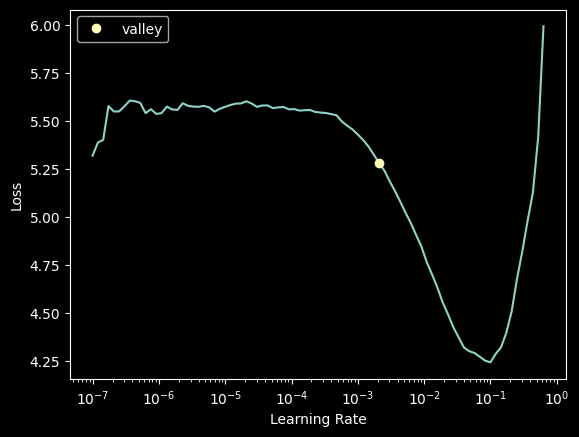

In [80]:


class SelectiveRotation(RandTransform):
    """
    Applies rotation to images except for those with specified labels.
    """
    def __init__(self, labels_to_avoid, degrees=10, **kwargs):
        super().__init__(**kwargs)
        self.labels_to_avoid = labels_to_avoid
        self.degrees = degrees

    def encodes(self, x: PILImage):
        # Extract label from file path, assuming label is the name of the parent directory
        label_name = x.parent.name
        if label_name not in self.labels_to_avoid:
            # Apply rotation
            degree = random.uniform(-self.degrees, self.degrees)
            x = x.rotate(degree)
        return x
    

def get_data_loaders_and_model(data_id=0, model=models.resnet50):
    data = load_pickle(f'data{data_id}.pickle')

    def get_label_from_path(item: Path):
        label = item.parent.name
        # Debug output
       # print(f"Reading path: {item}, Label extracted: {label}")
        return label

    path = Path(f'Data/_4GB/data{data_id}images')

    all_labels = sorted(set([p.parent.name for p in get_image_files(path)]))
    print("All labels found:", all_labels)  # Debug output

    reg_signs = DataBlock(
        blocks=(ImageBlock, CategoryBlock(vocab=all_labels)),
        get_items=get_image_files,
        splitter=GrandparentSplitter(
            train_name=f'data{data_id}train', valid_name=f'data{data_id}validation'),
        get_y=get_label_from_path,
        item_tfms=Resize(224),
    )

    labels_to_avoid = [str(label) for label in [38, 39, 36, 37]]

    aug_signs = DataBlock(
        blocks=(ImageBlock, CategoryBlock(vocab=all_labels)),
        get_items=get_image_files,
        splitter=GrandparentSplitter(
            train_name=f'data{data_id}train', valid_name=f'data{data_id}validation'),
        get_y=get_label_from_path,
        item_tfms=Resize(224),
        batch_tfms=[*aug_transforms(mult=1.0, do_flip=True, flip_vert=False,
                                    max_warp=0.0), SelectiveRotation(labels_to_avoid, degrees=10)]
    )

    reg_dls = reg_signs.dataloaders(path)
    aug_dls = aug_signs.dataloaders(path)

    test_dir = f'data{data_id}test'
    test_dl = reg_dls.test_dl(get_image_files(path/test_dir), with_labels=True)

    color_channels = 3 if data_id < 4 else 1

    learn = vision_learner(reg_dls, model, loss_func=CrossEntropyLossFlat(),
                           metrics=accuracy, n_in=color_channels, n_out=len(data['labels']), pretrained=True)

    return reg_dls, aug_dls, test_dl, data['labels'], learn


data_id = 0 # (0-8) pickle files to pull data from
model = models.resnet34
#model = models.resnet50
reg_dls, aug_dls, test_dl, labels, learn = get_data_loaders_and_model(data_id=data_id, model=model)

learn.lr_find()

In [79]:
def print_data_samples(dl, name):
    print(f"Samples from {name}:")
    for xb, yb in dl:
        # Assuming xb is a batch of images and yb is a batch of labels
        for i, (x, y) in enumerate(zip(xb, yb)):
            img_path = dl.items[i]  # Get the path
            # Convert label index to actual label using the labels list if applicable
            label = dl.vocab[y] if hasattr(dl, 'vocab') else y
            print(f"Path: {img_path}, Label: {label}")
            if i >= 5:  # Print only first 5 samples to avoid too much output
                break
        break


print_data_samples(reg_dls.train, "Regular Training DataLoader")
print_data_samples(aug_dls.train, "Augmented Training DataLoader")
print_data_samples(test_dl, "Test DataLoader")

Samples from Regular Training DataLoader:
Reading path: Data/_4GB/data0images/data0train/33/image_51079.png, Label extracted: 33
Reading path: Data/_4GB/data0images/data0train/18/image_73849.png, Label extracted: 18
Reading path: Data/_4GB/data0images/data0train/29/image_29819.png, Label extracted: 29
Reading path: Data/_4GB/data0images/data0train/1/image_65351.png, Label extracted: 1
Reading path: Data/_4GB/data0images/data0train/18/image_70849.png, Label extracted: 18
Reading path: Data/_4GB/data0images/data0train/39/image_72546.png, Label extracted: 39
Reading path: Data/_4GB/data0images/data0train/40/image_52541.png, Label extracted: 40
Reading path: Data/_4GB/data0images/data0train/0/image_40777.png, Label extracted: 0
Reading path: Data/_4GB/data0images/data0train/6/image_54046.png, Label extracted: 6
Reading path: Data/_4GB/data0images/data0train/5/image_75357.png, Label extracted: 5
Reading path: Data/_4GB/data0images/data0train/3/image_52330.png, Label extracted: 3
Reading pat

### Step 2: Phase 1 Training - train frozen network on unaugmented data

In [4]:
# Train for 1-2 epochs with non-augmented data
suggested_lr = 0.0020892962347716093
# Layers are already frozen
learn.fit_one_cycle(3, lr_max=suggested_lr)  # 1-2 epochs

# Step 3: Phase 1 Training - train frozen network on augmented data

In [5]:
learn.dls = aug_dls

# Train for 2-3 more epochs with augmented data
learn.fit_one_cycle(2, lr_max=suggested_lr)

epoch,train_loss,valid_loss,accuracy,time
0,0.303330,0.438631,0.872789,11:17
1,0.249527,0.399802,0.876871,11:46


# Step 4: Phase 2 Training - Unfreeze the network and find the new learning rate

SuggestedLRs(valley=3.0199516913853586e-05)

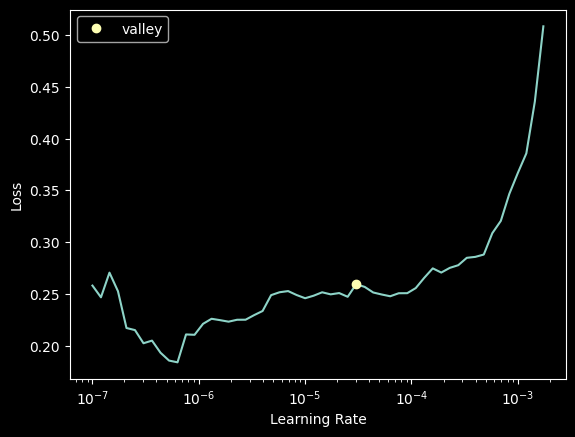

In [6]:
# Unfreeze the model
learn.unfreeze()
learn.lr_find()

# Step 5: Phase 2 Training - Set differential learning rates and train the whole network. 

* Differential Learning rates sets higher learning rates for the last layers and lower learning rates for first layers

In [7]:
# Set differential learning rates
# use suggested_lr for the high
high = 1.3182567499825382e-06
low = 10**-6.5
learn.fit_one_cycle(1, lr_max=slice(low, high))

epoch,train_loss,valid_loss,accuracy,time
0,0.243901,0.389830,0.878685,17:17


# Save Model

In [8]:
learn.save('data0ResNet34')

Path('models/data0ResNet34.pth')

# Load Model

### data0ResNet50

Using data0.pickle and the pre-trained ResNet50 model. 

1. The initial learning rate was found

2. Using the suggested learning rate, the model was trained for an additional 3 epochs on the data0 (non-augmented) data. 

3. Then the was unfrozen and the suggested learning rate was found again.

4. Using this suggested learning rate and another smaller learning rate (ie: $1/10$) differential learning rates were used to train the unfrozen model for one epoch.

5. After this stage, the test accuracy was very high, but the validation accuracy was very low. I decided to introduce augmented data at this stage and train the model for an additional two epochs with the most recently suggested learning rate. 

6. The final model was saved and the test accuracy was calculated:

Validation loss: 0.156088188290596
Validation accuracy: 0.9716553092002869
Test loss: 0.1470213681459427
Test accuracy: 0.9702296257019043


**NOTES**

The model seems to be mixing up ('Keep right', 'Keep left') and ('Go straight or right', 'Go straight or left'). Perhaps this is due to rotation in the data augmentation phase. 

* We could keep images with these labels from being rotated to possibly avoid the model's confusion

In [7]:
model = models.resnet34
#model = models.resnet50

data_id = 0
_, _, test_dl, labels, learn = get_data_loaders_and_model(data_id=data_id, model=model)
learn = learn.load('data0ResNet34') 
#learn = learn.load('data0ResNet50')

# Loss/Accuracy

In [38]:
val_loss, val_acc = learn.validate()
print(f'Validation loss: {val_loss}')
print(f'Validation accuracy: {val_acc}')

# Compute the test set loss and accuracy
test_loss, test_acc = learn.validate(dl=test_dl)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_acc}')

Validation loss: 10.709855079650879
Validation accuracy: 0.08253968507051468


Test loss: 0.1470213681459427
Test accuracy: 0.9702296257019043


pred_idx=  5
probs= tensor([7.9796e-05, 1.4028e-03, 3.9062e-05, 2.6396e-03, 5.0458e-03, 2.7924e-01,
        1.3057e-01, 8.0749e-04, 1.0099e-04, 1.6198e-02, 1.0183e-01, 1.3501e-04,
        6.8090e-04, 1.2606e-04, 2.7272e-05, 2.9020e-05, 3.2677e-05, 2.6316e-04,
        2.0372e-02, 3.7917e-03, 4.0816e-04, 1.7318e-04, 2.4574e-03, 6.3465e-02,
        1.6410e-04, 7.3907e-04, 8.0371e-05, 1.4718e-02, 4.4262e-02, 7.7747e-02,
        4.1123e-04, 3.0381e-05, 1.8581e-01, 3.3660e-03, 2.6776e-04, 7.5141e-04,
        1.6565e-05, 1.0238e-05, 4.5852e-03, 7.1127e-05, 1.2041e-03, 3.5359e-02,
        4.9138e-04])
True = 0, Pred = 13


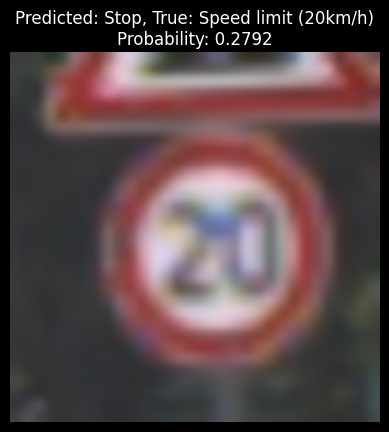

In [16]:
from fastai.vision.all import *
from PIL import Image
import matplotlib.pyplot as plt


def plot_prediction(image_path, learner):

    labels = pd.read_csv('./Data/_4GB/label_names.csv')

    # Load the image
    img = PILImage.create(image_path)
    img = img.resize((224, 224))

    # Predict the label
    pred, pred_idx, probs = learner.predict(img)
    print(f"pred_idx=  {pred_idx}")
    print(f"probs= {probs}")
    # Extract the true label from the file path
    true = image_path.parent.name

    predicted_label = labels['SignName'].iloc[int(pred)]
    true_label = labels['SignName'].iloc[int(true)]
    print(f"True = {true}, Pred = {pred}")

    # Plot the image with predicted and true labels
    plt.imshow(img)
    plt.title(
        f'Predicted: {predicted_label}, True: {true_label}\nProbability: {probs[pred_idx]:.4f}')
    plt.axis('off')
    plt.show()

# Image path (assuming the image is stored in one of the test set directories)
image_path = Path('./Data/_4GB/data0images/data0test/0/image_143.png')
plot_prediction(image_path, learn)

In [36]:
data = load_pickle()
labels = data['labels']

In [37]:
labels

['Speed limit (20km/h)',
 'Speed limit (30km/h)',
 'Speed limit (50km/h)',
 'Speed limit (60km/h)',
 'Speed limit (70km/h)',
 'Speed limit (80km/h)',
 'End of speed limit (80km/h)',
 'Speed limit (100km/h)',
 'Speed limit (120km/h)',
 'No passing',
 'No passing for vehicles over 3.5 metric tons',
 'Right-of-way at the next intersection',
 'Priority road',
 'Yield',
 'Stop',
 'No vehicles',
 'Vehicles over 3.5 metric tons prohibited',
 'No entry',
 'General caution',
 'Dangerous curve to the left',
 'Dangerous curve to the right',
 'Double curve',
 'Bumpy road',
 'Slippery road',
 'Road narrows on the right',
 'Road work',
 'Traffic signals',
 'Pedestrians',
 'Children crossing',
 'Bicycles crossing',
 'Beware of ice/snow',
 'Wild animals crossing',
 'End of all speed and passing limits',
 'Turn right ahead',
 'Turn left ahead',
 'Ahead only',
 'Go straight or right',
 'Go straight or left',
 'Keep right',
 'Keep left',
 'Roundabout mandatory',
 'End of no passing',
 'End of no passing 

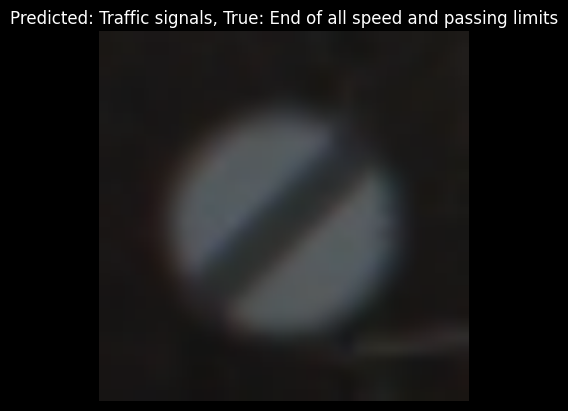

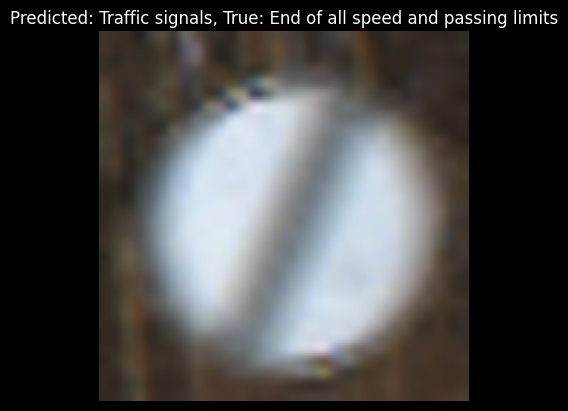

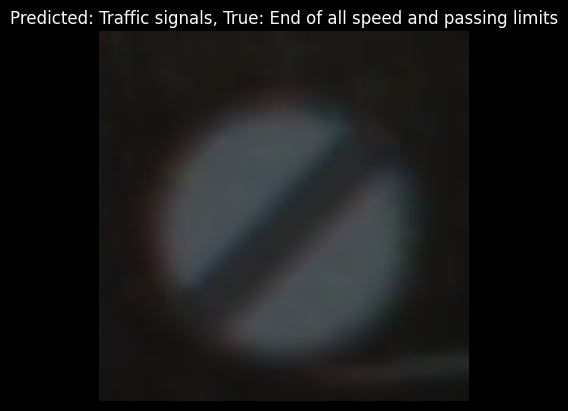

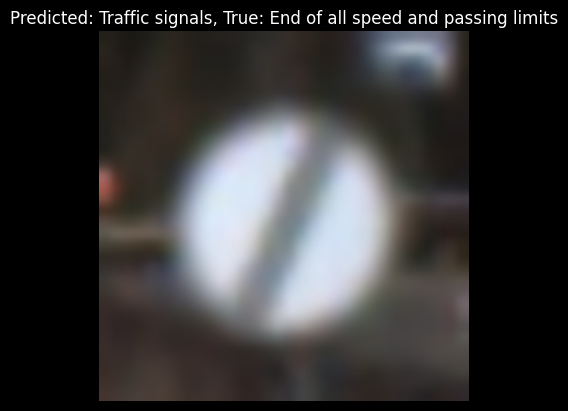

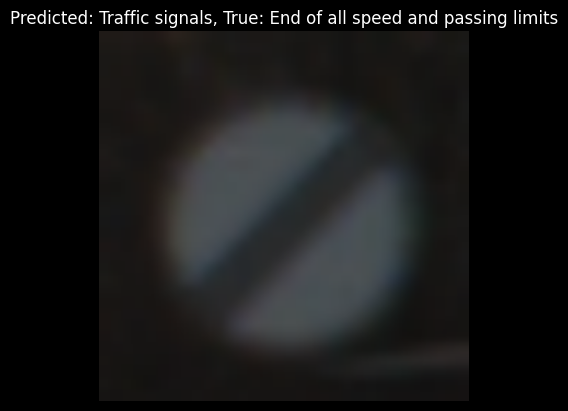

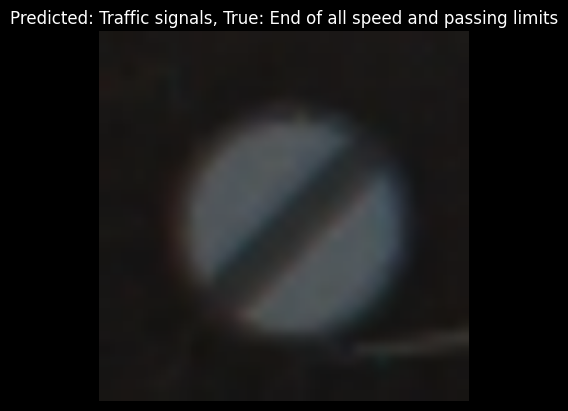

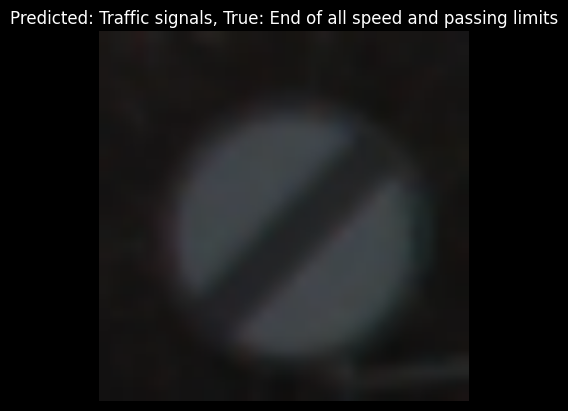

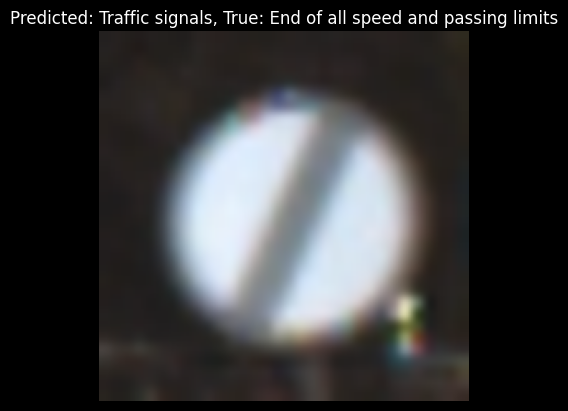

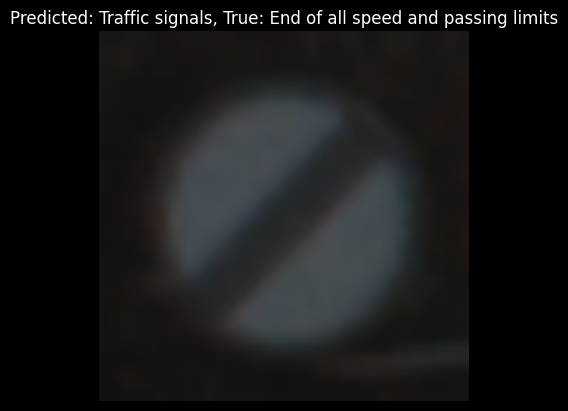

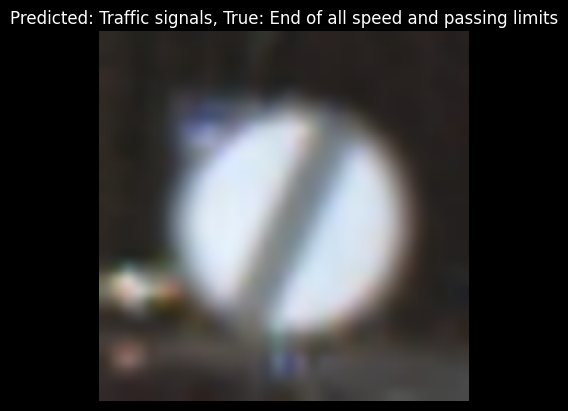

In [45]:
from fastai.vision.all import *
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def plot_prediction(image_path, labels, pred):
    

    # Load the image
    img = PILImage.create(image_path)
    # Ensure the image is resized as per model's training
    img = img.resize((224, 224))

    # Extract the true label from the file path
    true = image_path.parent.name

    # Mapping indices to actual label names
    predicted_label = labels['SignName'].iloc[int(pred)]
    true_label = labels['SignName'].iloc[int(true)]

    # Plot the image with predicted and true labels
    plt.imshow(img)
    plt.title(
        f'Predicted: {predicted_label}, True: {true_label}')
    plt.axis('off')
    plt.show()

labels = pd.read_csv('./Data/_4GB/label_names.csv')
# Get predictions and actual labels
preds, y_true = learn.get_preds(dl=test_dl)
pred_indices = preds.argmax(dim=1)

# Get image paths from the test dataloader directly
test_items = test_dl.items

# Filter and display only correct predictions
count = 0
for (pred, true, img_path) in zip(pred_indices, y_true, test_items):
    if pred == true and count < 10:
       plot_prediction(img_path, labels, pred)
       count += 1

In [46]:
# Extract a few batches from the test data loader and print paths and labels
for x, y in test_dl:
    for xi, yi in zip(x, y):
        print(f"Label: {yi}, Path: {test_dl.dataset.items[yi]}")
    break  # Just check the first batch for a quick inspection

Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategory(26, device='mps:0'), Path: Data/_4GB/data0images/data0test/32/image_280.png
Label: TensorCategor

In [41]:
count_correct/total

0.9702296120348377

In [20]:
preds, y_true = learn.get_preds(dl=test_dl)

In [21]:
len(preds), len(y_true)

(12630, 12630)

In [31]:
data = load_pickle()
labels = data['labels']


# Convert probabilities to predicted class indices
pred_indices = preds.argmax(dim=1)

# Loop through the predictions and true labels
for pred_idx, true_idx in zip(pred_indices, y_true):
    if pred_idx == true_idx:
        # Fetch the label using the index
        label = labels[true_idx.item()]  # Convert tensor to integer if needed
        print(f"Successfully predicted label: {label}")

Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traffic signals
Successfully predicted label: Traf

# Confusion Matrix

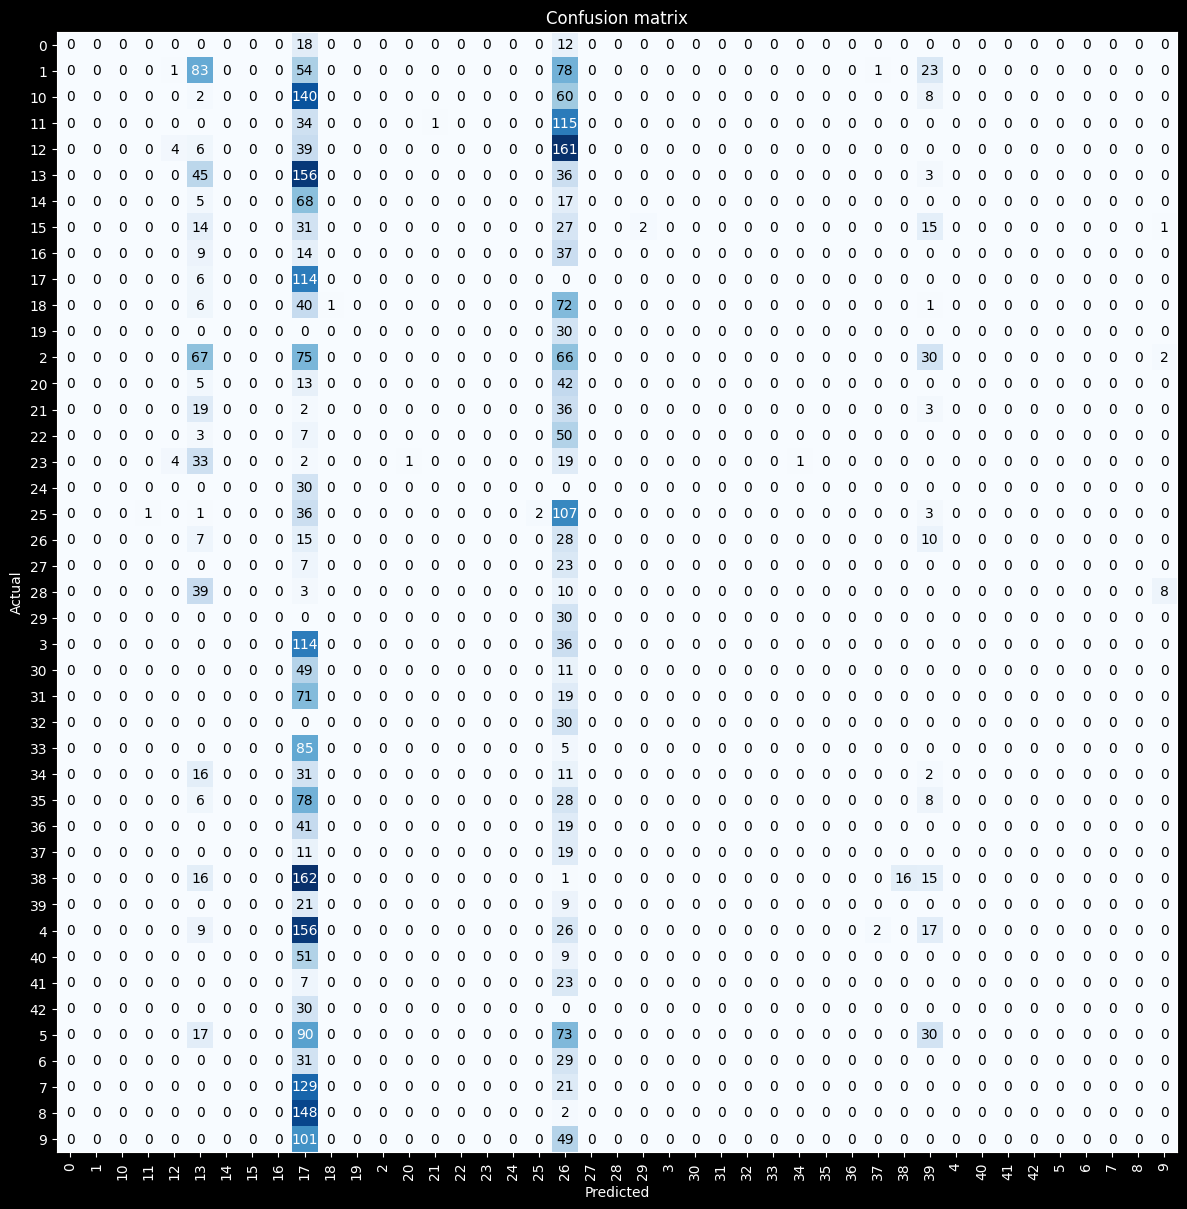

In [11]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12, 12))

# Top Losses

In [35]:
labels[38], labels[39], labels[36], labels[37]

('Keep right', 'Keep left', 'Go straight or right', 'Go straight or left')

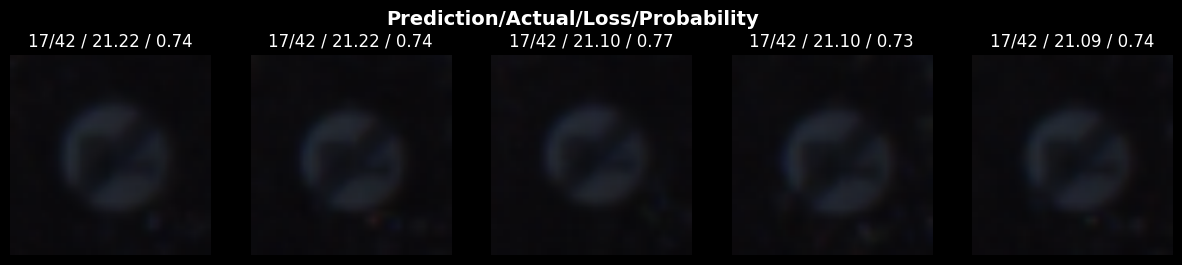

In [12]:
interp.plot_top_losses(5, nrows=1)

# Classification Report

In [14]:
from sklearn.metrics import classification_report
data = load_pickle(f'data0.pickle')
class_names = data['labels']
preds, y_true = learn.get_preds(dl=test_dl)
y_pred = np.argmax(preds, axis=1)
report = classification_report(y_true, y_pred, target_names=class_names)

print(report)

                                                    precision    recall  f1-score   support

                              Speed limit (20km/h)       0.92      0.97      0.94        60
                              Speed limit (30km/h)       0.86      0.93      0.89       720
                              Speed limit (50km/h)       0.98      0.95      0.97       660
                              Speed limit (60km/h)       0.98      0.96      0.97       420
                              Speed limit (70km/h)       1.00      0.91      0.95       690
                              Speed limit (80km/h)       0.94      0.99      0.97       720
                       End of speed limit (80km/h)       0.98      1.00      0.99       270
                             Speed limit (100km/h)       0.98      0.99      0.99       210
                             Speed limit (120km/h)       0.97      1.00      0.99       150
                                        No passing       1.00      0.98      0.

# ROC/AUC

In [15]:
def plot_average_roc(y_true, y_pred_probs, classes, n_classes):
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(), y_pred_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and ROC area

    # First aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Then interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    # Finally average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot all ROC curves
    plt.figure(figsize=(8, 6))

    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC curve (area = {0:0.2f})'.format(
                 roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot(fpr["macro"], tpr["macro"],
             label='Macro-average ROC curve (area = {0:0.2f})'.format(
                 roc_auc["macro"]),
             color='navy', linestyle=':', linewidth=4)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Average ROC Curves')
    plt.legend(loc="lower right")
    plt.show()

def plot_multi_class_roc_auc(y_true, y_pred, classes):
    """
    Plot ROC curve and calculate AUC for each class in a multi-class classification problem.

    Args:
    - y_true (array-like): True binary labels or binary label indicators (n_samples, n_classes).
    - y_pred (array-like): Target scores, can either be probability estimates of the positive class,
                           confidence values, or non-thresholded measure of decisions (n_samples, n_classes).
    - classes (list): List containing the labels of the classes.
    """
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(), y_pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve for each class and micro-averaged ROC curve
    plt.figure(figsize=(10, 8))
    lw = 2
    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=lw,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                       ''.format(classes[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC and AUC')
    plt.legend(loc="lower right")
    plt.show()

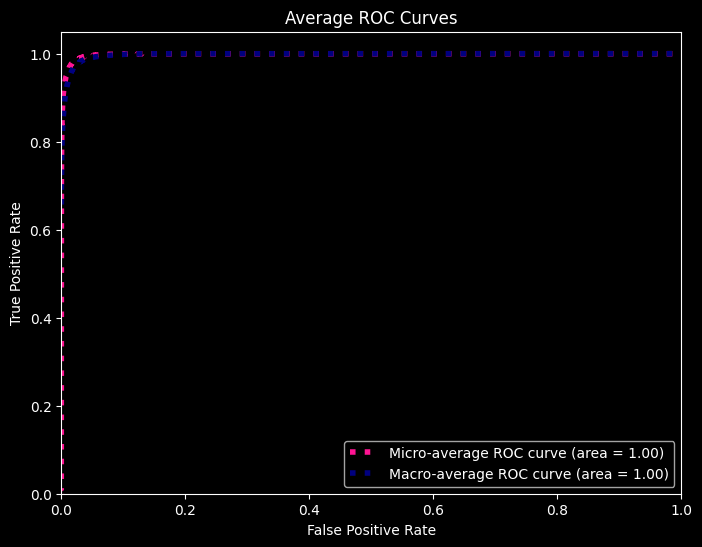

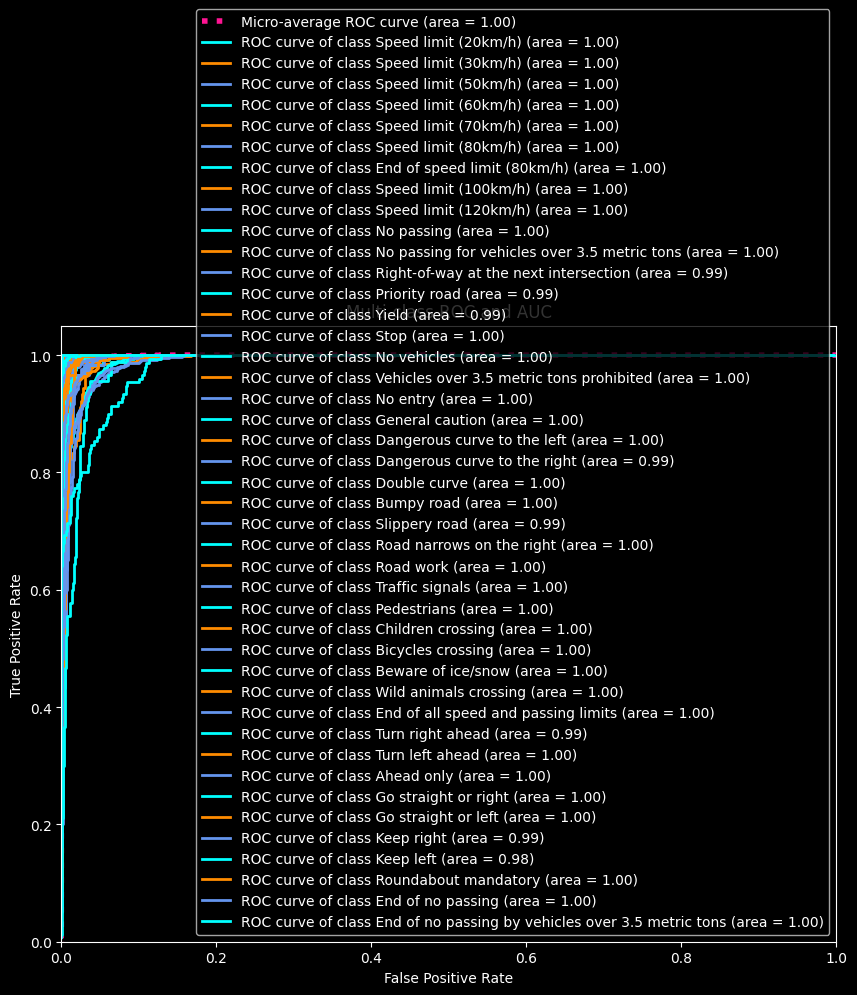

In [16]:

preds, y_true = learn.get_preds(dl=test_dl)
class_names = data['labels']
plot_average_roc(y_true.numpy(), preds.numpy(), class_names, len(class_names))

plot_multi_class_roc_auc(y_true.numpy(), preds.numpy(), class_names)